<a href="https://colab.research.google.com/github/tarabelo/GrIA-QML-2025-26/blob/main/04.%20Algoritmos%20cu%C3%A1nticos%20de%20optimizaci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install qiskit[visualization] qiskit_algorithms qiskit_optimization

# **Algoritmos cuánticos de optimización**

### Contenidos

1. [Introducción a los problemas de optimización](#intro)
1. [Problemas de optimización binaria cuadrática sin restricciones (QUBO) y modelo Ising](#qubo)
1. [Problemas de optimización binaria con restricciones](#restricciones)
1. [Computación cuántica adiabática y Quantum Annealing](#adiabatica)
1. [Algoritmos variacionales y circuitos parametrizados](#variacionales)
1. [Algoritmo cuántico de optimización aproximada (QAOA)](#qaoa)

Ejercicios

1. [Ejercicio entregable 6: suma de subconjuntos](#e6)
1. [Ejercicio entregable 7: reparto de turnos de trabajo](#e6)
1. [Ejercicio entregable 8: suma de subconjuntos con QAOA](#e8)

<a name="intro"></a>
# **Introducción a los problemas de optimización**

Muchos problemas relevantes en ciencia, ingeniería, economía o inteligencia artificial pueden expresarse como **problemas de optimización**. En términos generales, un problema de optimización consiste en encontrar los valores de ciertas variables que **minimizan** o **maximizan** una **función objetivo**, respetando una serie de **restricciones**.

Formalmente, un problema de optimización puede escribirse como:

$$
\begin{aligned}
\text{Minimizar (o maximizar)} \quad & f(x_1, x_2, \dots, x_n) \\
\text{sujeto a} \quad & g_i(x_1, \dots, x_n) \leq 0, \quad i = 1, \dots, m \\
& h_j(x_1, \dots, x_n) = 0, \quad j = 1, \dots, p
\end{aligned}
$$

donde:
- $f$ es la función objetivo,
- $g_i$ son restricciones de desigualdad,
- $h_j$ son restricciones de igualdad,
- y las variables $x_k$ pueden ser reales, enteras, binarias o discretas.



### Ejemplos clásicos de problemas de optimización

- **Problema del viajante (TSP)**: Dado un conjunto de ciudades y las distancias entre ellas, encontrar el camino más corto que visite cada ciudad exactamente una vez y regrese al punto de origen.

- **Problema de la mochila (Knapsack)**: Dados objetos con un peso y un valor, seleccionar un subconjunto cuyo peso total no exceda una capacidad dada y cuyo valor total sea máximo.

- **Coloración de grafos**: Asignar colores a los nodos de un grafo de forma que nodos adyacentes no compartan color y se minimice el número total de colores utilizados.

- **Problema de satisfacibilidad booleana (SAT)**: Determinar si existe una asignación de valores booleanos a un conjunto de variables que satisfaga una fórmula lógica.

- **Programación lineal binaria/entera**: Optimizar una función lineal sujeta a restricciones lineales, donde las variables sólo pueden tomar valores binarios/enteros.

Muchos de estos problemas son [**NP-duros**](https://es.wikipedia.org/wiki/NP-hard), es decir, su complejidad crece exponencialmente con el tamaño del problema.


<details>
<summary>Resumen sobre las clases de complejidad computacional</summary>

Cuando hablamos de la **complejidad computacional** de un problema, nos referimos a la cantidad de recursos (tiempo y/o espacio) necesarios para resolverlo en función del tamaño de la entrada. Esto se formaliza mediante **clases de complejidad**, que agrupan problemas según los recursos requeridos por sus algoritmos.

### Clases principales

#### 🔹 P (Polynomial Time)
- Conjunto de problemas que pueden resolverse en **tiempo polinómico** por una máquina determinista.
- Es decir, existen algoritmos eficientes que resuelven el problema con un coste $O(n^k)$, para alguna constante $k$.
- **Ejemplo**: ordenamiento de una lista, búsqueda en un grafo no ponderado.

#### 🔹 NP (Nondeterministic Polynomial Time)
- Problemas cuya solución puede **verificarse** en tiempo polinómico, aunque no sepamos cómo **encontrarla** eficientemente.
- Incluye todos los problemas de P (es decir, $\text{P} \subseteq \text{NP}$).
- **Ejemplo**: SAT, TSP, coloreado de grafos, problema de la mochila.

#### 🔹 NP-completo
- Subconjunto de NP que incluye los problemas **más difíciles** de la clase.
- Un problema es NP-completo si:
  1. Pertenece a NP.
  2. Todo problema en NP puede reducirse a él en tiempo polinómico.
- Si se resuelve uno en tiempo polinómico, **todos los problemas de NP también se pueden resolver eficientemente**.
- **Ejemplo**: SAT (el primer problema demostrado como NP-completo), 3-COLOR, TSP en su versión de decisión (determinar si existe un camino menor o igual que un valor dado).

#### 🔹 NP-duro (NP-hard)
- Problemas **al menos tan difíciles** como los NP-completos, pero **no necesariamente pertenecen a NP** (por ejemplo, pueden no tener soluciones verificables en tiempo polinómico).
- Suelen ser problemas de optimización o de decisión más generales.
- **Ejemplo**: versión de optimización del TSP (encontrar el camino más corto), QUBO, etc.

### ¿P = NP?

La pregunta de si $\text{P} = \text{NP}$ es uno de los problemas abiertos más importantes de la informática teórica. Si se demuestra que $\text{P} = \text{NP}$, todos los problemas cuya solución se puede verificar eficientemente también podrían **resolverse** eficientemente, lo que tendría enormes implicaciones en criptografía, planificación, diseño automático, etc.

---

### Clases de complejidad cuántica

#### 🔹 BQP (Bounded-error Quantum Polynomial Time)
- Problemas que pueden resolverse en **tiempo polinómico por una computadora cuántica** con un error de probabilidad acotado (< 1/3).
- Es la **contraparte cuántica de P**, e incluye algunos problemas que no se sabe cómo resolver eficientemente con algoritmos clásicos.
- **Ejemplo**: factorización de enteros (algoritmo de Shor), logaritmo discreto, simulación de sistemas cuánticos.

$$
\text{P} \subseteq \text{BPP} \subseteq \text{BQP}
$$

Donde **BPP** (Bounded-error Probabilistic Polynomial time) representa problemas que pueden resolverse eficientemente con algoritmos probabilísticos clásicos.

#### 🔹 QMA (Quantum Merlin-Arthur)
- Contraparte cuántica de **NP**: problemas para los que un verificador cuántico puede comprobar una prueba cuántica en tiempo polinómico.
- Existen problemas QMA-completos, como ciertas versiones del **problema del Hamiltoniano local**.

---

### Relaciones generales entre clases (parcialmente conocidas)

- Se sabe que:

$$
\text{P} \subseteq \text{NP}, \quad \text{P} \subseteq \text{BQP}
$$

- Pero **no se conoce** si:

$$
\text{NP} \subseteq \text{BQP} \quad \text{o si} \quad \text{BQP} \subseteq \text{NP}
$$

---

### Relevancia para la computación cuántica

Problemas como **QUBO** o el **modelo de Ising** pertenecen a la clase **NP-hard** y, en general, **no se espera** que puedan resolverse eficientemente en computadoras clásicas. Sin embargo, ciertos algoritmos cuánticos como el **Quantum Annealing** (usado en D-Wave) o el **QAOA (Quantum Approximate Optimization Algorithm)** ofrecen aproximaciones prometedoras, que caen dentro (o cerca) de la clase BQP o heurísticas asociadas.

---

</details>

En lo que sigue, nos centraremos en el problema **QUBO**, una formulación central para representar problemas de optimización combinatoria, tanto en su versión clásica como en su versión cuántica.


<a name="qubo"></a>
# **Problemas de optimización binaria cuadrática sin restricciones (QUBO) y modelo Ising**

Un tipo de problemas en los que se está usando la computación cuántica son los denominados [QUBO](https://en.wikipedia.org/wiki/Quadratic_unconstrained_binary_optimization) (_Quadratic Unconstrained Binary Optimization_).

Este tipo de problemas consisten en minimizar una función $f_Q(x)$ con la siguiente forma:

$$
f_Q(x) = x^TQx = \sum_{i=0}^{n-1}\sum_{j=0}^i q_{ij}x_ix_j
$$

donde $Q \in \mathbb{R}^{n\times n}$ es una matriz triangular y $x$ un vector de componentes binarias ($x_i \in \{0,1\}$).

Los problemas QUBO son [NP-duros](https://es.wikipedia.org/wiki/NP-hard).

Muchos modelos de optimización combinatoria pueden expresarse como problemas QUBO, por ejemplo modelos de programación lineal o problemas como el coloreado de grafos o el problema del viajante.


### Ejemplo: algoritmo MAX-CUT

Sea $G = (V, E)$ un grafo pesado no dirigido con $n$-nodos y pesos $w_{ij}>0$, $w_{ij}=w_{ji}$, con $(i,j)\in E$ y $w_{ij}=0$ si $(i,j)\notin E$.

Objetivo: dividir el grafo en dos conjuntos tal que la suma de los pesos de las aristas entre ambos conjuntos sea máximo.


<center><img src="https://drive.google.com/uc?export=view&id=1t37PWgnsVWRkX16wcbmFSPZNZ1D0dUOS" alt="Ejemplo MAX-CUT" width="700"  /></center>

En este grafo, los nodos $0$ y $3$ se asignan a un conjunto y $1$, $2$ y $4$ al otro. El peso del corte es $19$.

El algoritmo procede asignando a cada vértice un valor $x_i = \{0,1\}$ de forma que el grafo queda dividido en dos conjuntos: los vértices con $x_i = 0$ y aquellos con $x_i = 1$.

El algoritmo MAX-CUT busca el número binario $\textbf{x}=x_0\cdots x_{n-1}$ que maximice la función de coste:

$$
C(\textbf{x}) = \sum_{i,j = 0}^{n-1} w_{ij} x_i (1-x_j)
$$

siendo $w_{i,j} \ne 0$ solo si $(i,j) \in E$.

Si los vértices $i$ y $j$ están en el mismo conjunto: $x_i = x_j \Rightarrow x_i (1-x_j) = 0$.

Si los vértices $i$ y $j$ están en diferentes conjunto: $x_i \ne x_j \Rightarrow x_i (1-x_j) = 1$ ó $x_j (1-x_i) = 1$.

En la solución del grafo de la imagen podemos tener:

\begin{align}
x_0=x_3=0; x_1=x_2=x_4=1 → 01101\\
x_0=x_3=1; x_1=x_2=x_4=0 → 10010\\
\end{align}

y el peso es:

$$
C(01101) = w_{01}x_0(1-x_1)+ w_{10}x_1(1-x_0)+w_{12}x_1(1-x_2)+w_{21}x_2(1-x_1)+\\
w_{13}x_1(1-x_3)+w_{31}x_3(1-x_1)+w_{23}x_2(1-x_3)+w_{32}x_3(1-x_2)+\\
w_{24}x_2(1-x_4)+w_{42}x_4(1-x_2)+w_{34}x_3(1-x_4)+w_{43}x_4(1-x_3)=\\
w_{10}+w_{13}+w_{23}+w_{43} = 3+4+7+5 = 19
$$

Así, $C(\textbf{x})$ es la suma de los pesos de las aristas que separan ambos conjuntos.


### MAXCUT como problema QUBO
Los valores $w_{ij}$ son $\ne 0$ solo para las aristas del grafo.

Para una arista $(i,j)\in E$, los términos en $C(x)$ son:

$$
x_i(1-x_j) + x_j(1-x_i) = x_i+x_j-2x_ix_j
$$

Por tanto, podemos escribir la función de coste como:

$$
C(x) = \sum_{(i,j) \in E} w_{ij} (x_i + x_j - 2 x_i x_j) = \sum_{(i,j) \in E} w_{ij} (x_i - x_j)^2
$$
ya que $x_i^2 = x_i$ al ser valores binarios.

Para expresarlo como un **problema QUBO**, que requiere una **minimización**, usamos el negativo:

$$
f(x) = -\sum_{(i,j) \in E} w_{ij} (x_i + x_j - 2 x_i x_j)
$$

Es simple deducir que, dado que $w_{ij}=0, \forall (i,j)\notin E$,  podemos escribir:

$$
f(x) = -\sum_{i \in V} w^{(i)} x_i + \sum_{\substack{i,j \in V \\ j \gt i}} 2 w_{ij} x_i x_j
$$

siendo $w^{(i)} = \sum_{j\in V}w_{ij}$, es decir, la suma de los pesos de las aristas conectadas al vértice $i$.

#### Matriz $Q$ del QUBO

Reorganizamos la expresión en forma cuadrática:

$$
f(x) = x^T Q x
$$

Donde $Q \in \mathbb{R}^{n \times n}$ es una matriz triangular definida como:

$$
q_{ij} =
\begin{cases}
- w^{(i)} & \text{si } i = j \\
2 w_{ij} & \text{si } (i,j) \in E \text{ y } j \gt i \\
0 & \text{si } (i,j) \notin E
\end{cases}
$$

es decir, lor términos lineales aparecen en la diagonal y los cuadráticos fuera de la diagonal.

**Ejemplo**: grafo anterior como QUBO


La función de coste quedaría:

$$
\begin{align}
f(x) & = -\sum_{(i,j) \in E} w_{ij} (x_i + x_j - 2 x_i x_j) \\
& = w_{01} (x_0+x_1-2x_0x_1) - w_{12} (x_1+x_2-2x_1x_2) - w_{13} (x_1+x_3-2x_1x_3) \\
& - w_{23} (x_2+x_3-2x_2x_3) - w_{24} (x_2+x_4-2x_2x_4) - w_{34} (x_3+x_4-2x_3x_4)
\end{align}
$$

Juntando términos:

$$
\begin{align}
f(x) & = -w_{01}x_0-(w_{01}+w_{12}+ w_{13})x_1-(w_{12}+w_{23}+w_{24})x_2-(w_{13}+w_{23}+w_{34})x_3-(w_{24}+w_{34})x_4\\
& + 2(w_{01}x_0x_1 + w_{12}x_1x_2 + w_{13}x_1x_3 + w_{23}x_2x_3 + w_{24}x_2x_4 + w_{34}x_3x_4)
\end{align}
$$

Reemplazando los valores de los pesos:

$$
\begin{align}
f(x) & = -3x_0-(3+2+4)x_1-(2+7+1)x_2-(4+7+5)x_3-(1+5)x_4\\
& + 2(3x_0x_1 + 2x_1x_2 + 4x_1x_3 + 7x_2x_3 + 1x_2x_4 + 5x_3x_4)\\
& = -3x_0- 9x_1-10x_2-16x_3-6x_4\\
& + 6x_0x_1 + 4x_1x_2 + 8x_1x_3 + 14x_2x_3 + 2x_2x_4 + 10x_3x_4
\end{align}
$$

La matriz $Q$ correspondiente es:

$$
Q = \begin{pmatrix}
-3 &  6 & 0 & 0 & 0 \\
 0 & -9 & 4 & 8 & 0 \\
 0 &  0 & -10  & 14 & 2 \\
 0 &  0 & 0  & -16 & 10 \\
 0 &  0 & 0  & 0 & -6
\end{pmatrix}
$$

Se puede comprobar que:

$$
f(01101) = x^T Q x = -19
$$



---




## **Modelo Ising**

El [_modelo Ising_](https://en.wikipedia.org/wiki/Ising_model) es un modelo matemático usado en física estadística para estudiar el comportamiento de materiales ferromagnéticos.

Este modelo parte de una malla de $n$ partículas y busca minimizar el hamiltoniano:

$$
H(\textbf{z}) = -\sum_{(i,j) \in E} J_{ij}z_iz_j -\sum_j h_j z_j
$$

donde $z_i = \{-1,1\}$ representa el espín de la partícula $i$, $E$ el conjunto de aristas de la malla, $J_{ij}$ la energía de interacción entre dos partículas y $h_i$ la influencia de un campo magnético externo.

Resolver el problema permite obtener la configuración de espines correspondiente a un estado de mínima energía (o estado base).

**Ejemplo**:

<center><img src="https://drive.google.com/uc?export=view&id=1t8ii_V5HKX0sCVPKqgShQQzqTZOcXVxZ" alt="Malla Ising" width="500"  /></center>


En esta malla, suponiendo que $h_i=1, \forall{i}$, el Hamiltoniano resulta:

$$
H(\textbf{z}) = z_0z_1-3z_1z_2+z_2z_3-2z_0z_4+z_1z_5-3z_2z_6-2z_3z_7\\
+z_4z_5+z_5z_6+z_6z_7+z_4z_8-3z_5z_9+z_6z_{10}-z_7z_{11}\\
+z_8z_9-2z_9z_{10}+2z_{10}z_{11}-z_0-z_1-z_2-z_3-z_4-z_5\\
-z_6-z_7-z_8-z_9-z_{10}-z_{11}
$$

con $z_i = \{-1,1\}, \forall i$

Es posible demostrar que cualquier problema QUBO puede expresarse como un modelo Ising de forma simple.

### Expresión mediante operadores cuánticos

Supongamos la siguiente malla simple:

<center><img src="https://drive.google.com/uc?export=view&id=1pHIFMBSBWWciVhG1ll_SAKibigkHOiKz" alt="Malla Ising 3 nodos" width="350"  /></center>

En este caso, suponiendo ahora que $h_i=0, \forall{i}$, el problema queda como sigue:

\begin{align*}
\text{Minimizar}\quad & z_1 z_0 - 3z_2z_1 \\
\text{con}\quad & z_i = \{-1,1\}, i = 0,1,2
\end{align*}

Para el operador Pauli-Z, los valores esperados en los estados $|0\rangle$ y $|1\rangle$ son:

$$
\begin{aligned}
\langle 0|Z|0\rangle &= \begin{bmatrix}1 & 0\end{bmatrix}\begin{bmatrix}1 & 0\\0 & -1\end{bmatrix}\begin{bmatrix}1 \\ 0\end{bmatrix} = 1\\
\langle 1|Z|1\rangle &= \begin{bmatrix}0 & 1\end{bmatrix}\begin{bmatrix}1 & 0\\0 & -1\end{bmatrix}\begin{bmatrix}0 \\ 1\end{bmatrix} = -1
\end{aligned}
$$


Por lo tanto, podemos expresar el problema anterior como:

\begin{align*}
\text{Minimizar}\quad & \langle x_1|Z|x_1\rangle \langle x_0|Z|x_0\rangle - 3 \langle x_2|Z|x_2\rangle \langle x_1|Z|x_1\rangle\\
\text{con}\quad & x_i = \{0,1\}, i = 0,1,2
\end{align*}

Supongamos un estado base de un sistema de 3 cúbits, $|x\rangle = |x_2x_1x_0\rangle$ con $x_i = \{0,1\}$.

Podemos escribir:

$$
\langle x_1|Z|x_1\rangle \langle x_0|Z|x_0\rangle =
\langle x_2|I|x_2\rangle \langle x_1|Z|x_1\rangle \langle x_0|Z|x_0\rangle =
\langle x_2x_1x_0|I\otimes Z \otimes Z|x_2x_1x_0\rangle = \langle x|Z_1Z_0|x\rangle
$$

donde el operador $Z_i$ actúa sobre el cúbit $i$.

Por lo tanto, el problema anterior se puede expresar como buscar el estado base $|x_\text{min}\rangle$ que minimize la siguiente expresión:

$$
\langle x|Z_1Z_0|x\rangle - 3\langle x|Z_2Z_1|x\rangle = \langle x|Z_1Z_0-3Z_2Z_1|x\rangle = \langle x|H|x\rangle
$$
siendo H el observable $H=Z_1Z_0-3Z_2Z_1$

#### Generalización

Los términos lineales del modelo Ising se pueden expresar como:

$$
\sum_{j} h_j \langle x|Z_j|x\rangle
$$

Por lo que resolver el problema Ising es equivalente a **encontrar el estado $|x\rangle$ que minimiza**:

$$
\langle x|H|x\rangle = -\sum_{(i,j) \in E} J_{ij}\langle x|Z_iZ_j|x\rangle -\sum_j h_j \langle x|Z_j|x\rangle
$$

siendo $H$:

$$
H = -\sum_{(i,j) \in E} J_{ij}Z_iZ_j -\sum_j h_j Z_j
$$

Se puede demostrar que el mínimo de energía siempre se encuentra en uno de los estados base, por lo que podemos buscar el estado $\psi$ general que minimice:

$$
\langle \psi|H|\psi\rangle = -\sum_{(i,j) \in E} J_{ij}\langle\psi|Z_iZ_j|\psi\rangle -\sum_j h_j \langle\psi|Z_j|\psi\rangle
$$

y que será la solución del problema.

**Ejemplo**: para la malla Ising de tres nodos encuentra por fuerza bruta usando Qiskit el/los estado/s de la base $|x_\text{min}\rangle$ que minimizan el Hamiltoniano $H = Z_1Z_0-3Z_2Z_1$



In [ ]:
from qiskit.quantum_info import SparsePauliOp

n = 3

# Definimos el operador hamiltoniano
Z1Z0 = SparsePauliOp('IZZ')
Z2Z1 = SparsePauliOp('ZZI')

operador = Z1Z0 - 3*Z2Z1

# Otra forma
# operador = SparsePauliOp.from_list([('IZZ',1), ('ZZI',-3)])

print(operador)


In [ ]:
from qiskit.quantum_info import Statevector

# Creamos una lista con todos los estados base para n cúbits

estados = [Statevector.from_int(i, dims=2**n) for i in range(2**n)]

for i in range(2**n):
  print('Estado ',i, 'valor esperado=',estados[i].expectation_value(operador).real)

Los estados $|001\rangle$ y $|110\rangle$ obtienen el valor esperado mínimo (-4).

Estos estados corresponde a $z_1=z_2=\pm 1$ y $z_0\ne z_1$

## **Equivalencia QUBO $\leftrightarrow$ Ising**

Es fácil comprobar que es posible convertir un problema QUBO, con $x_i\in \{0,1\}$, en un problema Ising, con $z_i \in \{-1,1\}$, y viceversa, con un simple cambio de variables:

$$
z_i = 1 - 2x_i =
\begin{cases}
1, \text{si } x_i = 0 \\
-1, \text{si } x_i = 1
\end{cases}
$$





---



---



---



<a name="ejercicio1"></a>
## 💻 Ejercicio: Resolver MAX-CUT

Para el grafo de la imagen, obtén la formula analítica del problema MAXCUT en formato Ising, haciendo el cambio de variable a partir de la formulación QUBO, y resuelvelo por fuerza bruta usando Qiskit (crea el Hamiltoniano y obtén la energía de todos los estados). Indica también cómo obtener el peso del corte.

<center><img src="https://drive.google.com/uc?export=view&id=1t37PWgnsVWRkX16wcbmFSPZNZ1D0dUOS" alt="Ejemplo MAX-CUT" width="700"  /></center>


Para este ejemplo, habíamos obtenido la función de coste como:
$$
f(x)  = -3x_0- 9x_1-10x_2-16x_3-6x_4 + 6x_0x_1 + 4x_1x_2 + 8x_1x_3 + 14x_2x_3 + 2x_2x_4 + 10x_3x_4
$$

Para obtener la versión Ising tenemos que hacer el cambio de variable:

$$
x_i = \frac{z_i-1}{2}
$$

Podemos usar la librería SimPy de álgebra simbólica para obtener la expresión Ising

In [ ]:
from sympy import symbols, expand

n=5
# Variables x
x = symbols(f'x0:{n}')

expr_qubo = (-3*x[0] - 9*x[1] - 10*x[2] - 16*x[3] - 6*x[4]
             + 6*x[0]*x[1] + 4*x[1]*x[2] + 8*x[1]*x[3]
             + 14*x[2]*x[3] + 2*x[2]*x[4]
             + 10*x[3]*x[4])

print(f'Expresion QUBO = {expr_qubo}\n')

# Variables z
z = symbols(f'z0:{n}')

# Crear diccionario de sustitución
subs_dict = {x[i]: (1 - z[i])/2 for i in range(n)}

# Substituye
expr_ising = expr_qubo.subs(subs_dict)

# Expandimos la expresión
expr_ising = expand(expr_ising)

# En este caso no es necesario, pero si apareciesen terminos z_i²
# podríamos indicar que usase la propiedad z_i² = 1
expr_ising = expr_ising.subs({z[i]**2: 1 for i in range(n)})

print(f'Expresion Ising = {expr_ising}')



---



---



---



<a name="e6"></a>
# **✍️ Ejercicio entregable 6: suma de subconjuntos**

Problema de la [**suma de subconjuntos**](https://en.wikipedia.org/wiki/Subset_sum_problem) (*subset sum*): dado un conjunto de enteros $S = \{s_i\}$ y un entero $T$ ¿existe un subconjunto de $S$ cuya suma sea igual a $T$?

Se trata de un problema importante en la teoría de la complejidad y en la criptografía. Se sabe que es NP-completo.

Escribe en formato QUBO el problema para $S=\{-3, 2, -2, 5, 1\}$ y $T=-4$. Igual que antes, obtén la formula analítica del problema en formato Ising (haciendo el cambio de variable) y resuelvelo por fuerza bruta usando Qiskit (crea el Hamiltoniano y obtén la energía de todos los estados).

----

----

---



<a name="restricciones"></a>
## **Problemas de optimización binaria con restricciones**

La mayoría de los problemas de optimización suelen incluir restricciones:

- Esas restricciónes se pueden añadir la función objetivo para obtener un nuevo QUBO.

### **Programación binaria lineal (BLP)**

Problemas de optimización binaria con una función objetivo lineal y restricciones lineales:

$$
\begin{aligned}
\text{Minimizar} \quad & c_0x_0+c_1x_1+\dots +c_{n-1}x_{n-1} \\
\text{sujeto a} \quad & Ax \le b, \\
& x_i = \{0,1\}
\end{aligned}
$$

con $c_i,a_{ij},b_j \in \mathbb{Z}$ (se pueden extender a coeficientes reales).


Es posible escribir un problema de este tipo como un problema QUBO usando variables de holgura (*slack variables*) y  términos de penalización (*penalty terms*).



**Ejemplo**:

$$
\begin{aligned}
\text{Minimizar} \quad & -5x_0+3x_1-2x_2 \\
\text{sujeto a} \quad & x_0+x_2 \le 1, \\
& 3x_0-x_1+3x_2 \le 4 \\
& x_i = \{0,1\}
\end{aligned}
$$

Paso 1: Convertir las restricciones de desigualdad en igualdades usando **variables de holgura binarias**.

$$
x_0+x_2 \le 1 \Leftrightarrow  x_0+x_2+s_0 = 1, \text{ con } s_0\in\{0,1\}
$$

$$
3x_0-x_1+3x_2 \le 4 \Leftrightarrow  3x_0-x_1+3x_2 + s_1 = 4, \text{ con } s_1\in [0,5]
$$

El valor de $s_1$ en este caso viene dado porque el valor mínimo de $3x_0-x_1+3x_2$ es $-1$, por lo que la igualdad se verifica con $s_1=5$.

Podemos expresar $s_1$ con variables binarias haciendo:

$$
s_1 = s_{11}+2s_{12}+2s_{13}, \text{ con } s_{1i}\in\{0,1\}
$$

De esta forma, el problema original se puede escribir como:

$$
\begin{aligned}
\text{Minimizar} \quad & -5x_0+3x_1-2x_2 \\
\text{sujeto a} \quad & x_0+x_2+s_0-1 = 0, \\
& 3x_0-x_1+3x_2+s_{11}+2s_{12}+2s_{13}-4=0 \\
& x_i,s_i = \{0,1\}
\end{aligned}
$$

Las dos restricciones las podemos incluir en la función a minimizar como **términos de penalización** para obtener una formulación QUBO:

$$
\begin{aligned}
\text{Minimizar} \quad & -5x_0+3x_1-2x_2+P(x_0+x_2+s_0-1)^2+P(3x_0-x_1+3x_2+s_{11}+2s_{12}+2s_{13}-4)^2 \\
 & \text{con }x_i,s_i = \{0,1\}
\end{aligned}
$$

siendo $P$ una constante entera (denominada *multiplicador de Lagrange*) suficientemente grande para garantizar que no se escoge una solución que no cumpla las restricciones.

Por ejemplo, en este ejemplo como $-5x_0+3x_1-2x_2 \in [-7,3]$ si se toma $
P=11$ cualquier solución que no verifique alguna de las restricciones no será mínima.


#### Selección de los multiplicadores de Lagrange

- Si $P$ es demasiado pequeño, se van a obtener soluciones que no verifiquen las restricciones.

- Si $P$ es demasiado grande pueden aparecer problemas de mal condicionamiento numérico y mayor probabilidad de caer en mínimos locales.

Como regla, se puede elegir $P$ de forma que los valores de la penalización estén en el orden de los valores del objetivo.

<a name="otros"></a>

## **Otros problemas de optimización**

Existen otras formulaciones para problemas de optimización, según el tipo de variables y la imposición de restricciones:

Algunos ejemplos son:

*   Programación entera lineal (*Integer Lineal Programming*, ILP).
    - Variables $x_i\in \mathbb{Z}$.
*   Programación cuadrática con restricciones cuadráticas (_Quadratically Constrained Quadratic Programming_, QCQP).
    - Función objetivo cuadrática y restricciones cuadráticas

Este tipo de problemas pueden expresarse como problemas QUBO con ciertas limitaciones.








---



---



---



<a name="adiabatica"></a>
# **Computación cuántica adiabática y Quantum Annealing**

La computación cuántica adiabática es una forma alternativa de computación cuántica basada en la evolución temporal de un Hamiltoniano y en el [teorema adiabático](https://en.wikipedia.org/wiki/Adiabatic_theorem)

#### Ecuación de Schrödinger

La evolución temporal de un sistema cuántico viene dada por la ecuación de Schrödinger dependiente del tiempo:

$$i\hbar \frac{d}{d t}|\psi(t)\rangle = H(t)|\psi(t)\rangle$$

$H(t)$ es el Hamiltoniano del sistema en el instante $t$ y define la energía del mismo.


#### Teorema adiabático
Si un sistema cuántico está en un estado base (estado de menor energía o _ground state_) de un Hamiltoniano inicial y se le hace evolucionar muy lentamente hacia un Hamiltoniano final, este estado inicial evolucionará al estado base del Hamiltoniano final, tras un tiempo suficientemente largo.

Supongamos que tenemos un Hamiltoniano $H_c$ (_Hamiltoniano de coste_) cuyo estado base codifica la solución de nuestro problema.

Partimos de un Hamiltoniano $H_0$ cuyo estado base es facil de preparar y queremos llegar, en un tiempo $T$, al estado base de $H_c$. Hacemos evolucionar el sistema desde $t=0$ hasta $t=T$ como sigue:

$$H(t) = A(t)H_0 + B(t)H_c$$

donde las funciones $A$ y $B$ verifican: $A(0) = B(T) = 1$ y $A(T) = B(0) = 0$.

Un ejemplo de estas funciones son

$$
A(t) =  \left(1-\frac{t}{T}\right)\\
B(t) = \frac{t}{T}
$$


Si $t$ cambia muy lentamente, el sistema pasa de $H(0) = H_0$ a $H(T) = H_c$ manteniéndose en el estado base.

Midiendo el estado del sistema en $t=T$ obtenemos el estado $|\psi\rangle$ que minimiza $\langle\psi|H_c|\psi\rangle$ y que es la solución del problema.

En [Aharonov et al. 2007](https://doi.org/10.1137/080734479) se demostró que la computación cuántica adiabática es equivalente a la computación cuántica basada en puertas.

## **Quantum annealing**

La computación cuántica adiabática pura no es viable: el tiempo de evolución $T$ puede ser demasiado grande.

El Quantum annealing (QA) es un modelo similar a la computación cuántica adiabática, con ciertas limitaciones:

- El Hamiltoniano final tiene que ser un Hamiltoniano Ising:  

$$
H_c = -\sum_{i,j=0}^{n-1} J_{ij}Z_iZ_j - \sum_{i=0}^{n-1} h_{i}Z_i
$$

- No se mantiene la evolución adiabática $\implies$ el estado final podría no ser el estado base de $H_c$

**Estado inicial $H_0$**

Se suele usar como estado inicial el siguiente Hamiltoniano:

$$
H_0 = -\sum_{i=0}^{n-1} X_i
$$

Este estado se denomina _mixing Hamiltonian_ y su estado de menor energía es $|\psi_0\rangle = |+\rangle^{\otimes n}$

**Evolución del Hamiltoniano**

La evolución viene dada por:

$$
H(t) = A(t)H_0 + B(t)H_c = -A(t)\sum_{i=0}^{n-1} X_i - B(t)\sum_{i,j=0}^{n-1} J_{ij}Z_iZ_j - B(t)\sum_{i=0}^{n-1} h_{i}Z_i
$$


## **Quantum annealers**
Computadores cuánticos que resuelven problemas de optimización mediante Quantum annealing.

- [D-Wave Systems](https://www.dwavesys.com/): Primera empresa en vender quantum annealers
  - Último modelo [Advantage 2](https://www.dwavequantum.com/solutions-and-products/systems/)
      - Más de 4400 cúbits superconductores
      - Topología [Zephyr](https://www.dwavequantum.com/media/2uznec4s/14-1056a-a_zephyr_topology_of_d-wave_quantum_processors.pdf)
  - Suite Ocean: incluye diferentes paquetes, entre otros:
    - dwave-system: para enviar problemas a los sistemas cuánticos de D-Wave (incluyendo a través del servicio en la nube [Leap](https://cloud.dwavesys.com/)).
    - [dimod](https://docs.dwavequantum.com/en/latest/ocean/api_ref_dimod/index.html): para definir estructuras de datos y modelos matemáticos de diferentes tipos de problemas.
    - [dwave-networkx](https://docs.dwavequantum.com/en/latest/ocean/api_ref_dnx/index.html): integración con NetworkX para grafos.
    
  - Tipo de problemas: optimización de portfolios, optimización de rutas y gestión de flotas, optimización de líneas de producción, búsqueda de similaridad entre moléculas, etc.




In [ ]:
!pip install dwave-ocean-sdk

Para obtener la versión instalada:

In [ ]:
!dwave --version

DWave ofrecía un acceso gratuito general (limitado) a sus sistemas, pero lo canceló en enero de 2025:

  - El programa [Leap Quantum LaunchPad](https://www.dwavequantum.com/quantum-launchpad/) proporciona acceso por 3 meses a usuarios cualificados.

Al darse de alta, se obtiene una API key que se configura ejecutando:

In [ ]:
!dwave config create

## Solvers

Dwave proporciona diferentes resolutores (o [*samplers*](https://docs.dwavequantum.com/en/latest/ocean/api_ref_system/samplers.html)) según el tipo de problema y el hardware que se utiliza.

- [DWaveSampler](https://docs.dwavequantum.com/en/latest/ocean/api_ref_system/samplers.html#dwavesampler): sampler que envía problemas Binary Quadratic Model (BQM) (es decir, QUBO o Ising) directamente al Annealer
  - Utiliza problemas expresados como una matriz QUBO o a través de *dimod*

- Solvers híbridos (Leap Hybrid Solver Service (HSS))
  - Solvers híbridos accesibles a través de Leap
    - Utilizan sistemas clásicos y cuánticos

- Resolutores clásicos:
  - dimod.ExactSolver: resolutor por fuerza bruta
  - SimulatedAnnealingSampler: solver basado recocido simulado

#### Resolutores (samplers) híbridos
Sistemas híbridos cuántico/clásicos en la nube para resolver problemas formulados como modelos cuadráticos o no lineales.

- Hybrid BQM sampler ([LeapHybridSampler](https://docs.dwavequantum.com/en/latest/ocean/api_ref_system/samplers.html/leaphybridsampler)):
  - Modelos BQM más grandes de los que se pueden mandar directemente al annealer
  - Manda casi todo al annealer; la parte híbrida ayuda con la selección de parámetros, la escalabilidad y postprocesamiento.
- Hybrid CQM sampler ([LeapHybridCQMSampler](https://docs.dwavequantum.com/en/latest/ocean/api_ref_system/samplers.html#leaphybridcqmsampler)):  
  - Modelos cuadráticos con restricciones lineales o cuadráticas
  - Variables binarias, enteras y/o reales
  - Acepta restricciones **blandas** y **duras**
- Hybrid DQM sampler ([LeapHybridDQMSampler](https://docs.dwavequantum.com/en/latest/ocean/api_ref_system/samplers.html#leaphybriddqmsampler)):
  - Funciones cuadráticas en variables discretas categóricas
  - Las variables deben tomar valores de un conjunto finito y discreto
- Hybrid nonlinear-program sampler ([LeapHybridNLSampler](https://docs.dwavequantum.com/en/latest/ocean/api_ref_system/samplers.html#leaphybridnlsampler)):
  - Modelos de optimización no lineal en variables continuas o discretas.
  - Funciones objetivo y restricciones arbitrarias, incluyendo términos no polinómicos
  - Permite proporcionar estados de partida para acelerar la búsqueda

- [dwave-hybrid](https://docs.dwavequantum.com/en/latest/industrial_optimization/dwave_hybrid.html) permite crear un sampler híbrido personalizado
  - Permite combinar métodos clásicos y cuánticos en pipelines, iteraciones y workflows flexibles.

Estos solver pueden resultar más eficientes que usar solo el annealer.


## dimod

[dimod](https://docs.dwavequantum.com/en/latest/ocean/api_ref_dimod/) es la biblioteca base de D-Wave Ocean para representar distintos modelos de problemas con y sin restricciones, como los siguientes:

 - Modelos cuadráticos binarios (BQM), como QUBO o Ising: clase [BinaryQuadraticModel](https://docs.dwavequantum.com/en/latest/ocean/api_ref_dimod/models.html#module-dimod.binary.binary_quadratic_model)
 - Modelos cuadráticos (QM) con variables binarias o enteras: clase [QuadraticModel](https://docs.dwavequantum.com/en/latest/ocean/api_ref_dimod/models.html#module-dimod.quadratic.quadratic_model)
 - Modelos cuadráticos con restricciones (CQM) y variables binarias, enteras o reales: clase [ConstrainedQuadraticModel](https://docs.dwavequantum.com/en/latest/ocean/api_ref_dimod/models.html#module-dimod.constrained.constrained)
 - Modelos discretos cuadráticos (DQM): clase [DiscreteQuadraticModel](https://docs.dwavequantum.com/en/latest/ocean/api_ref_dimod/models.html#discrete-quadratic-models)

 También incluye otras funcionalidades como diferentes resolutores clásicos, por ejemplo solvers por fuerza bruta como [ExactSolver](https://docs.dwavequantum.com/en/latest/ocean/api_ref_dimod/sampler_composites.html#exact-solver),  [ExactCQMSolver](https://docs.dwavequantum.com/en/latest/ocean/api_ref_dimod/sampler_composites.html#exact-cqm-solver) y [ExactDQMSolver](https://docs.dwavequantum.com/en/latest/ocean/api_ref_dimod/sampler_composites.html#exact-dqm-solver)

### **Ejemplo**: Resolver problema Ising con DWaveSampler



<center><img src="https://drive.google.com/uc?export=view&id=1pHIFMBSBWWciVhG1ll_SAKibigkHOiKz" alt="Malla Ising 3 nodos" width="350"  /></center>

El Hamiltoniano Ising de esta malla es:
$$
H = -\sum_{(i,j) \in E} J_{ij} Z_iZ_j - \sum_j h_j Z_j = Z_0Z_1 - 3Z_1Z_2
$$

Es decir, $J_{01}=-1$, $J_{12} = 3$, $h_j=0$.

Lo expresamos como un BQM en dimod.

In [ ]:
from dimod import BinaryQuadraticModel, SPIN

J = {(0,1):-1, (1,2):3}
h = {}

# Expresamos el grafo simple como un modelo binario cuadrático
# SPIN: las variables toman valores {-1,1} (Ising)
problem = BinaryQuadraticModel(h, J, vartype=SPIN)
print("El problema a resolver es:")
print(problem)

#### Resolver en el Annealer a través de [Leap](https://cloud.dwavesys.com/leap)


Si tenemos acceso a los sistemas en la nube, para resolver el problema en un quantum annealer de DWave, haríamos:

In [ ]:
from dwave.system import DWaveSampler
from dwave.system import EmbeddingComposite

sampler = EmbeddingComposite(DWaveSampler())

# Hacemos 1000 ejecuciones
sampleset = sampler.sample(problem, num_reads=1000)
print("Las soluciones obtenidas son")
print(sampleset)

Principales funciones:

  - [DWaveSampler](https://docs.dwavequantum.com/en/latest/ocean/api_ref_system/samplers.html#dwavesampler): indica que se use un annealer como solver.
  - [EmbeddingComposite](https://docs.dwavequantum.com/en/latest/ocean/api_ref_system/composites.html#dwave.system.composites.EmbeddingComposite): mapea el problema en la configuración física del sistema DWave.

### Solución exacta y con annealing simulado

Dimod incluye un resolutor por fuerza bruta, que prueba todas las posibles combinaciones

In [ ]:
from dimod import ExactSolver
solver = ExactSolver()
sampleset = solver.sample(problem)
print(sampleset)

Podemos usar el simulador basado en annealing simulado

In [ ]:
# Usamos un annealing simulado
from dwave.samplers import SimulatedAnnealingSampler

# Usamos un simulador clásico en vez del D-WaveSampler
sampler = SimulatedAnnealingSampler()

# Ejecutamos 10 repeticiones
sampleset = sampler.sample(problem, num_reads=10)

print("\nLas soluciones obtenidas son:")
print(sampleset)




---



### **Ejemplo**: Resolver problema QUBO

MAXCUT del grafo:

<center><img src="https://drive.google.com/uc?export=view&id=1t37PWgnsVWRkX16wcbmFSPZNZ1D0dUOS" alt="Ejemplo MAX-CUT" width="700"  /></center>

Para este ejemplo, la función a minimizar era:
$$
f(x)  = -3x_0- 9x_1-10x_2-16x_3-6x_4 + 6x_0x_1 + 4x_1x_2 + 8x_1x_3 + 14x_2x_3 + 2x_2x_4 + 10x_3x_4
$$



In [ ]:
from dimod import Binary, BinaryQuadraticModel, BINARY
# Definimos lor terminos cuadráticos y los lineales
q = {(0,1):6, (1,2):4, (1,3):8, (2,3):14, (2,4):2, (3,4):10}
l = {0:-3, 1:-9, 2:-10, 3:-16, 4:-6}
# También serviría
#l = [-3, -9, -10, -16, -6]

# Definimos el modelo
bqm = BinaryQuadraticModel(l, q, vartype=BINARY)

print(bqm)

In [ ]:
# Usamos un annealing simulado
from dwave.samplers import SimulatedAnnealingSampler

# Usamos un simulador clásico en vez del D-WaveSampler
sampler = SimulatedAnnealingSampler()

# Ejecutamos 10 repeticiones
sampleset = sampler.sample(bqm, num_reads=10)

print("\nLas soluciones obtenidas son:")
print(sampleset)


También podemos definir el problema a partir de la matriz Q del QUBO.

In [ ]:
Q = {(0,0):-3, (1,1):-9, (2,2):-10, (3,3):-16, (4,4):-6,
        (0,1):6, (1,2):4, (1,3):8, (2,3):14, (2,4):2, (3,4):10}

bqm = BinaryQuadraticModel.from_qubo(Q)

sampler = SimulatedAnnealingSampler()

# Hacemos 10 ejecuciones
sampleset = sampler.sample(bqm, num_reads=10)
print("Las soluciones obtenidas son")
print(sampleset)

### Uso de _dwave-networkx_

El módulo dwave-networkx incluye métodos para resolver problemas de grafos, como el MAXCUT

- El grafo debe definirse usando la librería _networkx_ de Python


In [ ]:
import numpy as np
import networkx as nx  # Librería para manejar grafos
import dwave_networkx as dnx
from dwave.samplers import SimulatedAnnealingSampler

# Ejemplo de grafo con 5 nodos
nnodes = 5
G = nx.Graph()
# Añade nodos y aristas
G.add_nodes_from(np.arange(0,nnodes,1))
edges = [(0,1,3),(1,2,2),(1,3,4),(2,4,1),(2,3,7),(3,4,5)]
G.add_weighted_edges_from(edges)


# Obteniene los vértices que están en uno de los lados del corte usando annealing simulado
subset = dnx.weighted_maximum_cut(G, sampler=SimulatedAnnealingSampler())

print("Un lado del corte:", subset)
print("El otro lado:", G.nodes()-subset)

# Calcular aristas cortadas y peso total
cut_edges = [(int(u), int(v), G[u][v]['weight']) for u, v in G.edges() if (u in subset) ^ (v in subset)]
cut_value = sum(w for _, _, w in cut_edges)

print("Aristas cortadas:", cut_edges)
print("Peso total del corte:", cut_value)



---



## **Problemas binarios cuadráticos con restricciones (CQM)**

Supongamos un problema como este:
\begin{align*}
\text{Minimizar}\quad & -5x_0 +3 x_1 - 2x_2 \\
\text{sujeto a}\quad & x_0+x_2 \le 1, \\
& 3x_0-x_1+3x_2 \le 4,\\
& x_j \in \{0,1\}, j=0,1,2
\end{align*}

Usando dimod lo expresamos como un problema CQM (_Constrained cuadratic Model_) de la siguiente forma:

In [ ]:
from dimod import Binary, ConstrainedQuadraticModel
# Indicamos el tipo de las variables
x0, x1, x2 = Binary('x0'), Binary('x1'), Binary('x2')

# Definimos el modelo: función objetivo y restricciones
cqm = ConstrainedQuadraticModel()

# Añadimos el objetivo
cqm.set_objective(-5*x0+3*x1-2*x2)

# Primera restricción
cqm.add_constraint(x0+x2 <= 1, 'Primera restricción')

# Segunda restricción
cqm.add_constraint(3*x0-x1+3*x2 <= 4, 'Segunda restricción')

print(cqm)

Esta forma de expresar el problema (*symbolic math*) puede no ser útil en problemas reales.

Otra forma de hacer lo mismo:

In [ ]:
from dimod import BINARY, ConstrainedQuadraticModel

# Coeficientes de la función objetivo
coeffs = [-5, 3, -2]

# Coeficientes de las restricciones
coeffs_cons1 = [1, 0, 1]
coeffs_cons2 = [3,-1, 3]

# Creamos una lista de variables
variables = [f"x_{i}" for i in range(3)]

# Creamos una lista [('x_0', -5), ('x_1', 3), ('x_2', -2)]
objetivo = [*zip(variables, coeffs)]

# Modelo CQM
cqm2 = ConstrainedQuadraticModel()

# Añadimos las variables especificando que son binarias
cqm2.add_variables('BINARY', variables)

# Añade la funciómn objetivo
cqm2.objective.add_linear_from(objetivo)

# Primera restricción [('x_0', 1), ('x_1', 0), ('x_2', 1)] <= 1
cqm2.add_constraint([*zip(variables, coeffs_cons1)], sense="<=", rhs=1, label='Primera restricción')

# Segunda restricción [('x_0', 3), ('x_1', -1), ('x_2', 3)] <= 4
cqm2.add_constraint([*zip(variables, coeffs_cons2)], sense="<=", rhs=4, label='Segunda restricción')

print(cqm2)

Lo resolvemos por fuerza bruta usando el [ExactCQMSolver](https://docs.dwavequantum.com/en/latest/ocean/api_ref_dimod/sampler_composites.html#exact-cqm-solver) de dimod

In [ ]:
from dimod import ExactCQMSolver

# Resolver con ExactCQMSolver
solver = ExactCQMSolver()
sampleset = solver.sample_cqm(cqm)

print(sampleset)

# Mejor solución
best = sampleset.first
print("Mejor solución:", best.sample)
print("Valor objetivo:", best.energy)
print("¿Es factible? ", best.is_feasible)
print("¿Se satisfacen las restricciones? ", best.is_satisfied)

Entre las soluciones, incluye aquellas que no son factibles.

Para quedarnos con las soluciones que cumplen las restricciones, hacemos:

In [ ]:
solutions = sampleset.filter(lambda s: s.is_feasible)

print(solutions)

# Mejor solución factible
best = solutions.first
print("\nMejor solución factible:", best.sample)
print("Valor objetivo:", best.energy)
print("¿Es factible? ", best.is_feasible)
print("¿Se satisfacen las restricciones? ", best.is_satisfied)

### Resolver CQM en el Annealer

Para resolver el problema CQM en el Quantum Annealer hay dos opciones:

1. Usar un solver híbrido en Leap (en concreto, el [LeapHybridCQMSampler](https://docs.dwavequantum.com/en/latest/ocean/api_ref_system/samplers.html#leaphybridcqmsampler))
1. Convertir el problema en un BQM sin restricciones y usar DWaveSampler (o SimulatedAnnealingSampler para resolverlo en un sistema clásico)


#### Solución usando un Hybrid CQM Solver

In [ ]:
from dwave.system import LeapHybridCQMSampler

# Resolver con el Hybrid CQM Solver
sampler = LeapHybridCQMSampler()
sampleset = sampler.sample_cqm(cqm)

print(sampleset)

# Analizar resultados
solutions = sampleset.filter(lambda s: s.is_feasible)

# Mejor solución factible
best = solutions.first
print("\nMejor solución factible:", best.sample)
print("Valor objetivo:", best.energy)
print("¿Es factible? ", best.is_feasible)

#### Solución convirtiendo a BQM

Dimod tiene una utilidad que convierte de CQM a BQM sin restricciones: [`dimod.cqm_to_bqm`](https://docs.dwavequantum.com/en/latest/ocean/api_ref_dimod/generated/dimod.cqm_to_bqm.html)

  - Convierte el modelo usando variables de holgura y penalizaciones para las restricciones.
  - Es posible especificar el peso de las penalizaciones.

In [ ]:
from dimod import cqm_to_bqm

# invert permite obtener la solución del CQM a partir de la del BQM
bqm, invert = cqm_to_bqm(cqm, lagrange_multiplier=11)

print(bqm)

Resolvemos el problema BQM usando el annealing simulado

In [ ]:
from dwave.samplers import SimulatedAnnealingSampler

# Usamos un simulador clásico en vez del D-WaveSampler
sampler = SimulatedAnnealingSampler()

# Ejecutamos 10 repeticiones
sampleset = sampler.sample(bqm, num_reads=10)

print("\nLas soluciones obtenidas para el BQM son:")
print(sampleset)

Para obtener las soluciones del problema CQM original:

In [ ]:
for s in sampleset.data():
  print(f"Solución: {invert(s.sample)}\t Energía {s.energy}")




---



---



---



<a name="e7"></a>
# **✍️ Ejercicio entregable 7: reparto de turnos de trabajo**

En nuestra empresa se trabaja en cuatro turnos horarios, numerados del 0 al 3. Mediante una encuesta, se ha solocitado a los empleados que valoren de 1 a 4 su preferencia de turno (1 indica la más preferida y 4 la menos preferida). Los resultados son los de la tabla:

| Empleado  | Turno 0 | Turno 1 | Turno 2 | Turno 3 |
|-----------|---------|---------|---------|---------|
| Ana       | 1       | 2       | 3       | 4       |
| Benito    | 3       | 2       | 1       | 4       |
| Carlos    | 4       | 2       | 3       | 1       |
| Diana     | 4       | 1       | 2       | 3       |
| Enrique   | 1       | 2       | 3       | 4       |
| Fabio     | 3       | 2       | 1       | 4       |
| Gala      | 4       | 2       | 3       | 1       |
| Hugo      | 4       | 1       | 2       | 3       |


Queremos expresar el problema como un CQM y resolverlo por fuerza bruta usando el ExactCQMSolver (usaríamos el LeapHybridCQMSampler si tuviésemos acceso a Leap).

El modelo que vamos a definir considera un conjunto de variables binarias $x_{et}$ con $e \in {\text{empleados}}$ y $t \in \{0,1,2,3\}$ representa el turno. Si $x_{et} = 1$ el empleado $e$ se asigna al turno $t$. Notar que varios empleados pueden asignarse al mismo turno, pero cada empleado solo puede estar en un turno, es decir:

$$
\sum_{t=0}^3 x_{et} = 1, ∀ e
$$

La función a minimizar será la siguiente:

$$
\sum_{e \in {\text{empleados}}}\sum_{t=0}^3 \text{preferencia}_{et}x_{et}
$$



**Apartado 1**

En este primer caso, la única restricción es que cada empleado solo puede estar asignado a un turno.

Mira la función `build_cqm()` para añadir esa restricción para cada empleado.

Sugerencia: mira la función [`cqm.add_discrete`](https://docs.dwavequantum.com/en/latest/ocean/api_ref_dimod/generated/dimod.ConstrainedQuadraticModel.add_discrete.html#dimod-constrainedquadraticmodel-add-discrete), que permite indicar que para un empleado $e$ solo haya un 1 en $x_{et}, \forall t\in\{0,1,2,3\}$

In [ ]:
# TODO: Añade los imports necesarios


# Devuelve el sampler que vamos a usar
def set_sampler():
    '''Devuelve un sampler'''
    # TODO: especifica un sampler
    sampler =

    return sampler

# Empleados y preferencias
def employee_preferences():
    '''Devuelve un diccionario de empleados y sus preferencias'''

    preferences = { "Ana": [1,2,3,4],
                    "Benito": [3,2,1,4],
                    "Carlos": [4,2,3,1],
                    "Diana": [4,1,2,3],
                    "Enrique": [1,2,3,4],
                    "Fabio": [3,2,1,4],
                    "Gala": [4,2,3,1],
                    "Hugo": [4,1,2,3]}

    return preferences

# Crea y devuelve el modelo CQM
def build_cqm():
    '''Construye el CQM de nuestro problema'''

    preferences = employee_preferences()
    num_shifts = 4

    # TODO: Inicializa el objeto cqm
    cqm =

    # Recorre los nombres de los empleados y sus preferencias
    for employee, preference in preferences.items():
        # Crea etiquetas de la forma x_et para cada turno
        labels = [f"x_{employee}_{shift}" for shift in range(num_shifts)]

        # TODO: Añade la restricción de que cada empleado solo esté en un turno
        cqm.

        # Crea una lista [(labels, preferencia)]
        # por ejemplo: [('x_Ana_0', 1), ('x_Ana_1', 2), ('x_Ana_2', 3), ('x_Ana_3', 4)]
        # y la añade a la función objetivo
        cqm.objective.add_linear_from([*zip(labels, preference)])

    return cqm

# Resuelve el problema
def solve_problem(cqm, sampler):
    '''Resuelve en CQM usando el sampler'''

    # Obtiene el sampler
    sampler = set_sampler()

    # TODO: Resuelve el CQM usando el sampler
    # Recuerda verificar que la solución cumpla las restricciones
    sampleset =

    return sampleset

# Procesa la solución
def process_sampleset(sampleset):
    '''Procesa y muestra la mejor solución encontrada'''

    # Obtén la primer solución
    sample = sampleset.first.sample

    shift_schedule=[ [] for i in range(4)]

    # Obtiene una lista con el/los empleados asignados a cada turno
    for key, val in sample.items():
        if val == 1.0:
            name = key.split('_')[1]
            shift = int(key.split('_')[2])
            shift_schedule[shift].append(name)

    return shift_schedule

# Ejecuta el programa
shifts = [0, 1, 2, 3]
num_shifts = len(shifts)

cqm = build_cqm()

sampler = set_sampler()

sampleset = solve_problem(cqm, sampler)

shift_schedule = process_sampleset(sampleset)

for i in range(num_shifts):
    print("Turno:", shifts[i], "\tEmpleado(s): ", shift_schedule[i])

**Apartado 2**

Ahora queremos añadir las siguientes restricciones

1. Benito y Fabio no pueden trabajar durante el mismo turno
2. A Enrique y Hugo les gustaría trabajar en el mismo turno

Modifica la función `build_cqm()` para incorporar esas restricciones

In [ ]:
# TODO: Añade los imports necesarios


# Devuelve el samples que valos a usar
def set_sampler():
    '''Devuelve un sampler'''
    # TODO: especifica un sampler
    sampler =

    return sampler

# Empleados y preferencias
def employee_preferences():
    '''Devuelve un diccionario de empleados y sus preferencias'''

    preferences = { "Ana": [1,2,3,4],
                    "Benito": [3,2,1,4],
                    "Carlos": [4,2,3,1],
                    "Diana": [4,1,2,3],
                    "Enrique": [1,2,3,4],
                    "Fabio": [3,2,1,4],
                    "Gala": [4,2,3,1],
                    "Hugo": [4,1,2,3]}

    return preferences

# Crea y devuelve el modelo CQM
def build_cqm():
    '''Construye el CQM de nuestro problema con más restricciones'''

    preferences = employee_preferences()
    num_shifts = 4

    # TODO: Inicializa el objeto cqm
    cqm =

    # Recorre los nombres de los empleados y sus preferencias
    for employee, preference in preferences.items():
        # Crea etiquetas de la forma x_et para cada turno
        labels = [f"x_{employee}_{shift}" for shift in range(num_shifts)]

        # TODO: Añade la restricción de que cada empleado solo esté en un turno
        cqm.

        # Crea una lista [(labels, preferencia)]
        # por ejemplo: [('x_Ana_0', 1), ('x_Ana_1', 2), ('x_Ana_2', 3), ('x_Ana_3', 4)]
        # y la añade a la función objetivo
        cqm.objective.add_linear_from([*zip(labels, preference)])

    # TODO: Añade la restricción 1
    # Queremos penalizar que x_{Benito}{t} = x_{Fabio}{t} = 1, para algún t



    # TODO: Añade la restricción 2
    # En este caso, queremos que  x_{Enrique}{t} = x_{Hugo}{t} = 1, para algún t
    # Es decir, queremos penalizar los casos x_{Enrique}{t} != x_{Hugo}{t}



    return cqm

# Resuelve el problema
def solve_problem(cqm, sampler):
    '''Resuelve en CQM usando el sampler'''

    # Obtiene el sampler
    sampler = set_sampler()

    # TODO: Resuelve el CQM usando el sampler
    # Recuerda verificar que la solución cumpla las restricciones
    sampleset =

    return sampleset

# Procesa la solución
def process_sampleset(sampleset):
    '''Procesa y muestra la mejor solución encontrada'''

    # Obtén la primer solución
    sample = sampleset.first.sample

    shift_schedule=[ [] for i in range(4)]

    # Obtiene una lista con el/los empleados asignados a cada turno
    for key, val in sample.items():
        if val == 1.0:
            name = key.split('_')[1]
            shift = int(key.split('_')[2])
            shift_schedule[shift].append(name)

    return shift_schedule

# Ejecuta el programa
shifts = [0, 1, 2, 3]
num_shifts = len(shifts)

cqm = build_cqm()

sampler = set_sampler()

sampleset = solve_problem(cqm, sampler)

shift_schedule = process_sampleset(sampleset)

for i in range(num_shifts):
    print("Turno:", shifts[i], "\tEmpleado(s): ", shift_schedule[i])

**Apartado 3**

Modifica el código anterior para añadir dos nuevas restricciones:

1. Ana no puede trabajar en el turno 0
2. Tiene que haber un máximo de dos empleados por turno



---



---



---



<a name="variacionales"></a>
# **Algoritmos variacionales y circuitos parametrizados**



## **Algoritmos cuánticos variacionales**
Problema de los computadores cuánticos actuales: el ruído destruye la superposición de estado.

No es posible resolver un problema complejo (profundo) en un sistema actual: por ejemplo, la factorización de Shor podría necesitar millones de cúbits para corrección de errores.

Computadores actuales: _Noisy intermediate-scale quantum_ (NISQ)

Podemos pensar en dividir un problema complejo en partes más simples, y utilizar CPUs tradicionales en el proceso de optimización:

<center><img src="https://drive.google.com/uc?export=view&id=1WgpYw-cCkpuNZE2AOnPL4b3kIt9A_kU2" alt="Algoritmo híbrido" width="700"  /></center>

Esta estrategia también se denomina _Computación híbrida_.

Se basa en usar un circuito cuántico que incluye parámetros que se van optimizando. Este circuitos se  denomina *ansatz*, _forma (o circuito) variacional_ o, simplemente, circuito cuántico parametrizado.

<a name="parametros"></a>

## **Circuitos parametrizados en Qiskit**

Qiskit incluye métodos para facilitar la creación de circuitos parametrizados.

In [ ]:
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter, ParameterVector
import numpy as np

#Se crean los parámetros usando un string como identificador (no se les asigna ningún valor)
parameter_0 = Parameter('θ')
parameter_1 = Parameter('β')
circuit = QuantumCircuit(1)

#Podemos ahora usar los parámetros como ángulos de rotación en una puerta
circuit.ry(theta = parameter_0, qubit = 0)
circuit.rx(theta = parameter_1, qubit = 0)

circuit.draw('mpl')

Es posible definir vectores de parámetros

In [ ]:
# Numero de cubits y de parametros
n = 2
num_par = 2*n

# ParameterVectors se inicializan con un identificador y un entero que indica la longitud del string
parameters = ParameterVector('θ', num_par)

circuit = QuantumCircuit(n)

for i in range(n):
    circuit.ry(parameters[i], i)
    circuit.rx(parameters[i+n], i)

circuit.draw('mpl')

Finalmente, se dan valores a los parámetros.

In [ ]:
# Creamos un diccionario que asigna a cada parámetro un valor aleatorio
param_dict = {p: np.random.random() for p in parameters}
print(param_dict)

# El método assign_parameters permite ligar los valores al circuito
circuit_v = circuit.assign_parameters(parameters = param_dict)
circuit_v.draw('mpl')



---



---



---



<a name="qaoa"></a>
# **Algoritmo cuántico de optimización aproximada (QAOA)**

El Quantum Approximate Optimization Algorithm o QAOA (Farhi, E., Goldstone, J., \& Gutmann, S. 2014) es un algoritmo híbrido basado en la discretización de la evolución adiabática para resolver problemas Ising.

## **Discretización de la evolución adiabática (*Trotterization*)**

Podemos replicar la evolución adiabática en un computador cuántico basado en puertas discretizando la evolución continua del Hamiltoniano.

La evolución temporal de un sistema viene dada por la ecuación de Schrödinger:

$$i\hbar \frac{d}{dt}|\psi(t)\rangle = H(t)|\psi(t)\rangle$$

En general, $H(t)$ depende del tiempo. Pero en un intervalo temporal $[t_i, t_i+\Delta t]$ suficientemente pequeño podemos considerar $H(t_i)$ constante, verificándose que:

$$|\psi(t_i+\Delta t)\rangle = e^{-iH(t_i)\Delta t}|\psi(t_i)\rangle = U_i|\psi(t_i)\rangle$$

siendo $U_i = e^{-iH(t_i)\Delta t}$ una matriz unitaria.



Si discretizamos la evolución en $p = \frac{T}{\Delta t}$ pasos, podemos escribir:

$$
|\psi(t_1)\rangle = U_0|\psi(t_0)\rangle \\
|\psi(t_2)\rangle = U_1|\psi(t_1)\rangle \\
\cdots \\
|\psi(t_{p})\rangle = U_{p-1}|\psi(t_{p-1})\rangle
$$


De esta forma, el estado final del sistema será:

$$
|\psi(t_{p})\rangle = U_{p-1}U_{p-2}\cdots U_{1}U_{0}|\psi(t_0)\rangle = \left(\prod_{m=p-1}^{0} U_m\right) |\psi(t_0)\rangle
$$



El Hamiltoniano usado en computación adiabática es:

$$H(t) = A(t)H_0 + B(t)H_c$$

por lo que resulta:

$$
|\psi(T)\rangle = \left(\prod_{m=0}^{p-1} e^{i\Delta t(A'(t_m)H_0 + B'(t_m)H_c)}\right) |\psi(0)\rangle
$$

donde $A'(t_m) = -A(t_{p-1-m})$, $B'(t_m) = -B(t_{p-1-m})$, $|\psi(T)\rangle = |\psi(t_{p})\rangle$ y $|\psi(0)\rangle = |\psi(t_{0})\rangle$




En general, dadas dos matrices $A$ y $B$, la igualdad $e^{A+B} = e^Ae^B$ solo se da si $A$ y $B$ _conmutan_, es decir si $[A,B] = AB-BA = 0$.

Si $\Delta t$ es lo suficientemente pequeño y los hamiltonianos "casi" conmutan, la formula de Lie-Trotter de primer orden permite escribir:

$$
e^{i\Delta t(A'(t_m)H_0 + B'(t_m)H_c)}
= e^{i\Delta tA'(t_m)H_0} e^{i\Delta tB'(t_m)H_c} +
\mathcal{O}(t^2) \approx e^{i\Delta tA'(t_m)H_0} e^{i\Delta tB'(t_m)H_c}
$$

Esta aproximación se denomina _trotterization_ y es la base de algoritmos como el QAOA.

Usando _trotterization_, el estado final del sistema se puede escribir:

$$
|\psi_f\rangle = |\psi(T)\rangle = \left(\prod_{m=0}^{p-1} e^{i\Delta tA'(t_m)H_0} e^{i\Delta tB'(t_m)H_c}\right) |\psi(0)\rangle =
\prod_{m=0}^{p-1} U_0(t_m)U_c(t_m)|\psi_0\rangle
$$

siendo las matrices unitarias:

$$
U_0(t_m) = e^{i\Delta tA'(t_m)H_0} = e^{i\beta_mH_0} = U_0(\beta_m)\\
U_c(t_m) = e^{i\Delta tB'(t_m)H_c} = e^{i\gamma_mH_c} = U_c(\gamma_m)
$$
con $m=0,\ldots,p-1$ y $p \ge 1$.

QAOA intenta elegir unos valores de $\beta_m$ y $\gamma_m$ que aproximen el estado $|\psi_f\rangle$ al estado base del Hamiltoniano de coste $H_c$, es decir, que minimizen $\langle\psi_f|H_c|\psi_f\rangle$.

El algoritmo QAOA parte de un Hamiltoniano de coste $H_c$ que define el problema y procede como sigue:

1. Se elige un valor de $p\ge 1$ y dos listas de valores $\boldsymbol{\beta} = (\beta_0,\ldots,\beta_{p-1})$ y $\boldsymbol{\gamma} = (\gamma_0,\ldots,\gamma_{p-1})$
1. Como $H_0$ se suele usar el _mixing Hamiltonian_ o _mixer_ $H_M$ y como estado inicial la superposición completa (aunque se pueden usar otros)
  $$H_M = -\sum_{i=0}^{n-1} X_i\quad
  |\psi_0\rangle = |+\rangle^{\otimes n}$$
2. La QPU aplica las puertas $U_0(\beta_m)U_c(\gamma_m)$, $m=0,\ldots,p-1$, y se obtiene un nuevo estado $|\psi_p\rangle$
3. En la CPU se usa un algoritmo de optimización para actualizar los parámetros $\boldsymbol{\beta}$ y $\boldsymbol{\gamma}$ intentando minimizar el valor esperado $\langle\psi_p|H_c|\psi_p\rangle$
4. Se vuelve al paso 2 hasta obtener los valores óptimos $\boldsymbol{\beta}^\ast$ y $\boldsymbol{\gamma}^\ast$
5. Usando esos valores, se obtiene el estado que minimiza la solución

El proceso de optimización de los parámetros puede ser un simple gradiente descendente, en el que cada parámetro se actualiza en la dirección que conduzca al mayor descenso del valor esperado, u otros método de optimización más sofisticados.

## Construcción de $U_0(\beta)$ y $U_c(\gamma)$ para un problema Ising

#### Puertas para $U_0(\beta)$

Si tenemos $n$ cúbits, y dado que las matrices $X$ conmutan tenemos:

$$U_0(\beta) = e^{i\beta H_0} = e^{-i\beta\sum_{i=0}^{n-1} X_i} = \prod_{i=0}^{n-1}e^{-i\beta X_i}$$

Y recordando que la puerta de rotación $R_x(\theta) = e^{-i\theta X/2}$, se tiene:

$$U_0(\beta) = \prod_{i=0}^{n-1} R_x^{(i)}(2\beta)$$

La puerta $R_x^{(i)}$ indica que se aplica una $R_x$ al cúbit $i$ y la identidad al resto $\implies$ el producto equivale a aplicar una puerta $R_x(2\beta)$ a cada uno de los cúbits.

#### Puertas para $U_c(\gamma)$

El Hamiltoniano de coste de un problema Ising es:


$$H_c = -\sum_{i,j = 0}^{n-1} J_{ij}Z_iZ_j -\sum_{i = 0}^{n-1} h_i Z_i$$

siendo $J_{ij}$ y $h_i$ números reales.

Ya que las matricez $Z$ conmutan, podemos escribir

$$
U_c(\gamma) = e^{i\gamma H_c} = e^{-i\gamma(\sum_{i,j = 0}^{n-1} J_{ij}Z_iZ_j +\sum_{i = 0}^{n-1} h_i Z_i)} =
\prod_{i,j = 0}^{n-1}e^{-i\gamma J_{ij}Z_iZ_j}\prod_{i=0}^{n-1}e^{-i\gamma h_i Z_i}
$$

El segundo término se puede implementar con puertas $R_z(\theta) = e^{-i\theta Z/2}$.


Para el primer término, $Z_iZ_j$ representa aplicar una puerta $Z$ a los cúbits $i$ y $j$ y la identidad al resto:

$$
Z_iZ_j = I\otimes\ldots\otimes Z\otimes\ldots\otimes Z \otimes\ldots I = Z_i\otimes Z_j
$$

Y el término $e^{-i\gamma J_{ij}Z_i\otimes Z_j}$ corresponde a una [puerta Ising ZZ](https://qiskit.org/documentation/stubs/qiskit.circuit.library.RZZGate.html#qiskit.circuit.library.RZZGate) entre los cúbits $i$ y $j$:

$$
R_{ZZ}(\theta) = \exp\left(-i\frac{\theta}{2}(Z\otimes Z)\right) =
\exp{\left(-i\frac{\theta}{2}\begin{bmatrix}
1 & 0 & 0 & 0\\
0 & -1 & 0 & 0\\
0 & 0 & -1 & 0\\
0 & 0 & 0 & 1\\
\end{bmatrix} \right)}=
\begin{bmatrix}
e^{-i\theta/2} & 0 & 0 & 0\\
0 & e^{i\theta/2} & 0 & 0\\
0 & 0 & e^{i\theta/2} & 0\\
0 & 0 & 0 & e^{-i\theta/2}\\
\end{bmatrix}
$$

Con lo que queda:

$$
U_c(\gamma) = \prod_{i,j = 0}^{n-1} R_{ZZ}^{(i,j)}(2\gamma J_{ij})\prod_{i=0}^{n-1}R_z^{(i)}(2\gamma h_i)
$$




---



### **Ejemplo**: Circuito QAOA para un Hamiltoniano Ising

Obtener el circuito QAOA para un paso ($p$=1) del Hamiltoniano Ising:

$$
H_c = 3Z_2Z_0 - Z_2Z_1 + 2Z_0
$$

Necesitamos 3 cúbits, y el estado que queremos conseguir será:

$$
U_0(\beta)U_c(\gamma) |+\rangle^{\otimes 3}
$$

Con

$$
U_0(\beta) = \prod_{i=0}^{2} R_x^{(i)}(2\beta) = R_x^{(0)}(2\beta)\otimes R_x^{(1)}(2\beta)\otimes R_x^{(2)}(2\beta)
$$

$$
U_c(\gamma) = \prod_{i,j = 0}^{2} R_{ZZ}^{(i,j)}(2\gamma J_{ij})\prod_{i=0}^{2}R_z^{(i)}(2\gamma h_i) = (R_{ZZ}^{(2,0)}(6\gamma)\otimes R_{ZZ}^{(2,1)}(-2\gamma))(R_z^{(0)}(4\gamma))
$$

El circuito sería:

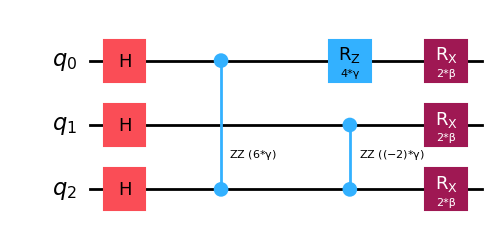

In [63]:
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter

n = 3

beta = Parameter('β')
gamma = Parameter('γ')

qc = QuantumCircuit(n)

# Estado superpuesto
qc.h(range(3))

# Puertas U_c
qc.rzz(6*gamma, 2, 0)
qc.rzz(-2*gamma, 2, 1)
qc.rz(4*gamma, 0)

# puertas U_0
for i in range(3):
  qc.rx(2*beta, i)

qc.draw('mpl')

Podemos usar la implementación de QAOA de Qiskit para obtener este mismo circuito

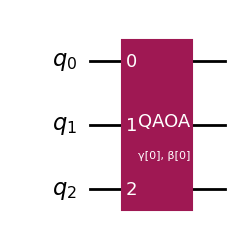

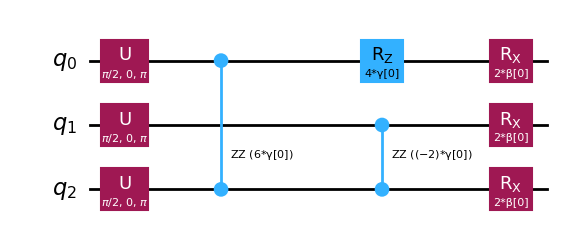

In [64]:
from qiskit.circuit.library import QAOAAnsatz
from qiskit.quantum_info import SparsePauliOp

# Expresamos el problema como un operador Hamiltoniano
Hc = SparsePauliOp.from_list([("ZIZ", 3), ("ZZI", -1), ("IIZ", 2)])

# Creamos el ansatz QAOA
ansatz = QAOAAnsatz(Hc, reps=1)

display(ansatz.draw("mpl"))
display(ansatz.decompose(reps=2).draw("mpl"))

Para resolverlo, podemos usar la implementación de [QAOA](https://qiskit-community.github.io/qiskit-algorithms/stubs/qiskit_algorithms.QAOA.html) del paquete [qiskit_algorithms](https://qiskit-community.github.io/qiskit-algorithms/apidocs/qiskit_algorithms.html).

- Tenemos que especificar el algoritmo clásico de optimización que vamos a usar

In [ ]:
from qiskit_algorithms import QAOA
from qiskit.primitives import StatevectorSampler
from qiskit_algorithms.optimizers import COBYLA
from qiskit_algorithms.utils import algorithm_globals

algorithm_globals.random_seed = 10598

# Parámetros iniciales
initial_gamma = np.pi
initial_beta = np.pi / 2

init_params = [initial_beta, initial_gamma]

# Especifico el optimizador
optimizer = COBYLA()

# Utilizo el sampler basado en vector de estado
sampler = StatevectorSampler()

# Defino el algoritmo
qaoa = QAOA(sampler=sampler, optimizer=optimizer, initial_point=init_params)

# Obtengo el mínimo autovalor del Hamiltoniano
result = qaoa.compute_minimum_eigenvalue(Hc)

min_state = result.best_measurement['bitstring']
ev = result.best_measurement['value']
print("Estado que minimiza Hc = {}".format(min_state))
print("Valor esperado <{}|Hc|{}> = {}\n".format(min_state, min_state, ev.real))

El circuito que utilizó:

In [ ]:
result.optimal_circuit.decompose(reps=2).draw('mpl')



---



---



---



<a name="e8"></a>
# **✍️ Ejercicio entregable 8: suma de subconjuntos con QAOA**


En el ejercicio 6, habíamos expresado como Ising el problema de la suma de subconjuntos para $S=\{-3, 2, -2, 5, 1\}$ y $T=-4$. Resuélvelo usando la implementación de QAOA de qiskit_algorithms




---



---



---



### **Referencia**

- Lucas, Andrew. "Ising formulations of many NP problems." Frontiers in physics 2 (2014): 5